In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
import sigkerax
from sigkerax.sigkernel import SigKernel
jax.config.update("jax_enable_x64", True)

# Allow the notebook to import from the parent directory
sys.path.append(os.path.abspath('..'))

from models.heston import simulate_heston
from models.bergomi import simulate_bergomi
from calibration import calibrate_heston_fourier_ad, calibrate_bergomi_mc_ad
from calibration.fourier_ad import newton_iv
from diagnostics.signature_mmd import compute_sig_mmd


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:

# Create your universal snapshot
market_snapshot = {
    "evaluation_date": "2017-10-23",
    "spot": 2564.98,
    "r": 0.0113,  
    "q": 0.00,    
    "options": pd.DataFrame({
        "T": [30/365, 30/365, 30/365, 90/365, 90/365, 90/365], # Time to maturity in years
        "K": [2400, 2564, 2600, 2400, 2564, 2600],             # Strikes
        "IV": [0.18, 0.12, 0.10, 0.19, 0.15, 0.14]             # Market Implied Volatility
    })
}

print(f"Market data loaded for {market_snapshot['evaluation_date']}")

Market data loaded for 2017-10-23


In [37]:

newton_iv(10, 100, 140, 1, 0.1, 0.0)

Array(0.46306197, dtype=float64)

In [38]:
print("Running Fourier/AD calibration natively in JAX...")

calibrated_params = calibrate_heston_fourier_ad(market_snapshot, steps=500, lr=0.05)

# Pack the required market parameters for the models/heston.py simulator
calibrated_params['S0'] = market_snapshot['spot']
calibrated_params['r'] = market_snapshot['r']
calibrated_params['q'] = market_snapshot.get('q', 0.0)

print("Calibrated Parameters ready for Simulation:")
for k, v in calibrated_params.items():
    print(f"  {k}: {v}")

Running Fourier/AD calibration natively in JAX...
Starting Heston Fourier/AD Calibration (Fixed Grid)...
Step 0 | RMSE: 0.056515
Step 100 | RMSE: 0.001040
Step 200 | RMSE: 0.000837
Step 300 | RMSE: 0.000658
Step 400 | RMSE: 0.000517
Calibrated Parameters ready for Simulation:
  kappa: 5.217793499268825
  theta: 0.05731639445173203
  sigma: 0.9278719092011353
  rho: -0.9976731949653166
  v0: 0.009750272599433698
  S0: 2564.98
  r: 0.0113
  q: 0.0


In [ ]:
print("Simulating path distributions natively on GPU...")

# Configure the simulation runs
key = jax.random.PRNGKey(42)
n_paths = 2048
n_steps = 100
T = 1.0


simulated_paths = simulate_heston(
    params=calibrated_params,
    key=key, 
    n_paths=n_paths, 
    n_steps=n_steps, 
    T=T
)

heston_paths = simulated_paths  # Store for signature MMD calculation
calib_key, sim_key = jax.random.split(key)  # Split keys for Bergomi

print(f"Simulation complete! Output shape: {simulated_paths.shape}")


Simulating path distributions natively on GPU...
Simulation complete! Output shape: (2048, 101, 2)


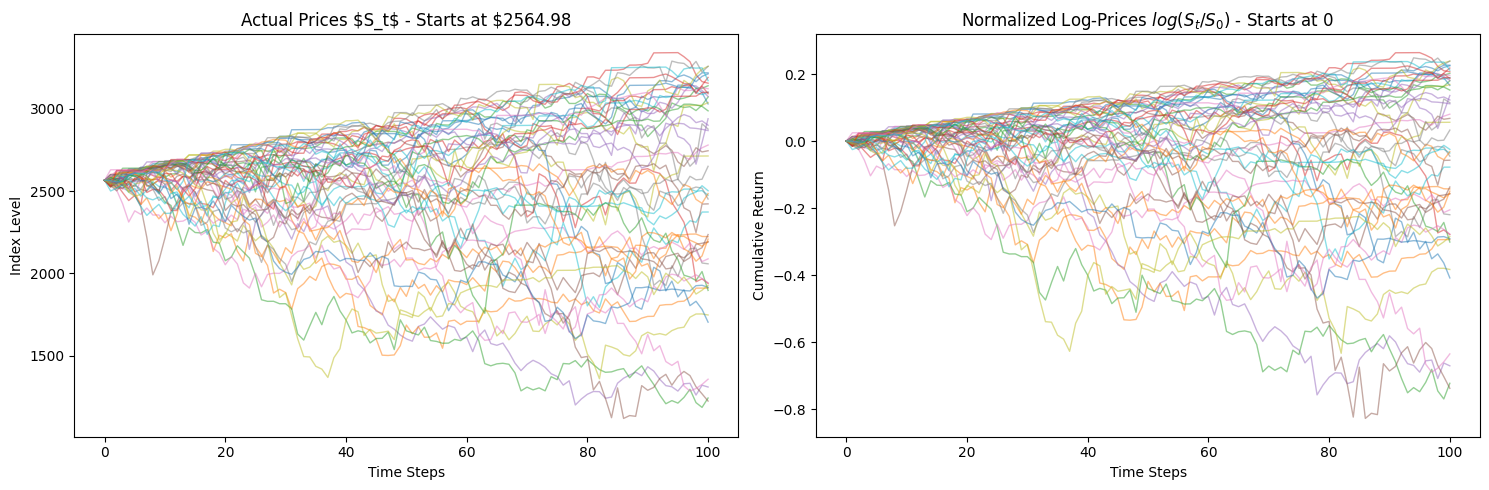

In [40]:
# Extract the log prices (feature 0) from your generated Heston tensor
# Shape is (2048, 101)
log_prices = simulated_paths[:, :, 0] 

# Exponentiate to get actual prices: S_t = exp(log_S_t)
actual_prices = jnp.exp(log_prices)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Actual Prices (Human Readable)
for i in range(50): # Just plotting the first 50 paths to avoid clutter
    ax1.plot(actual_prices[i, :], lw=1, alpha=0.5)
ax1.set_title("Actual Prices $S_t$ - Starts at $2564.98")
ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Index Level")

# Plot 2: Log Prices (What Sig-MMD sees)
for i in range(50):
    # Optional: Normalize so they all start at 0 for pure return visualization
    normalized_log_prices = log_prices[i, :] - log_prices[i, 0]
    ax2.plot(normalized_log_prices, lw=1, alpha=0.5)
ax2.set_title("Normalized Log-Prices $log(S_t/S_0)$ - Starts at 0")
ax2.set_xlabel("Time Steps")
ax2.set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()

<>:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/6g/xmgh_b_d4rz4b549wb6d2h0h0000gn/T/ipykernel_18318/2627109344.py:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax2.set_title("Normalized Log-Prices $\log(S_t/S_0)$ - Starts at 0")


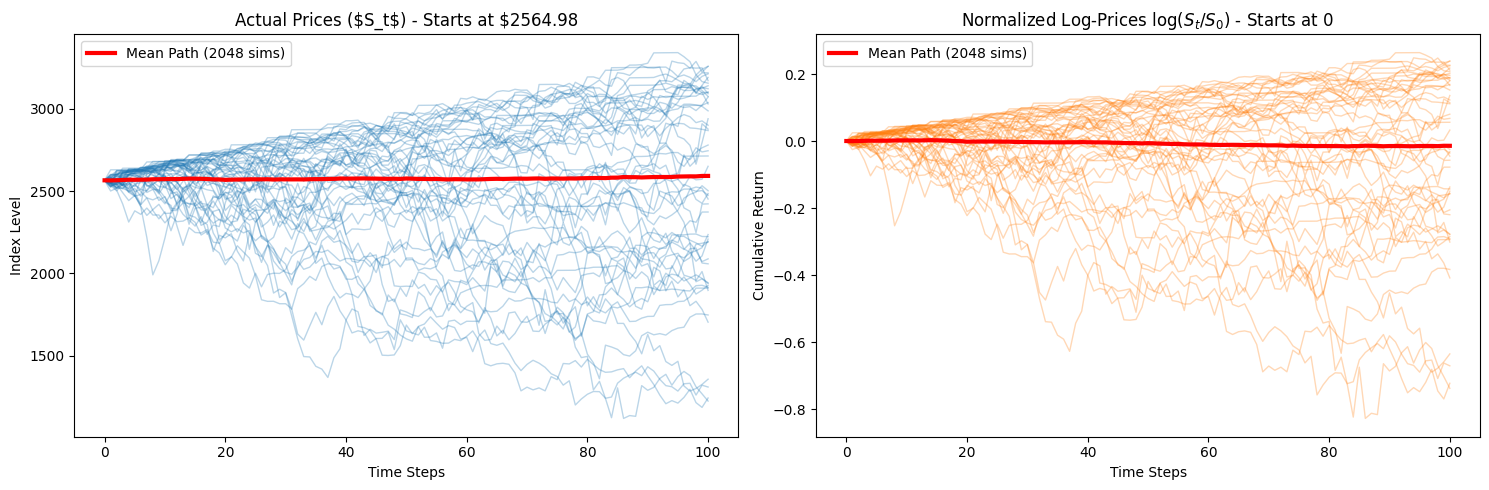

In [41]:
# Extract the log prices (feature 0) from your generated Heston tensor
# Shape is (2048, 101)
log_prices = simulated_paths[:, :, 0] 

# --- 1. Math for Actual Prices ---
actual_prices = jnp.exp(log_prices)
# Calculate the mean across the batch dimension (axis=0)
average_actual_price = jnp.mean(actual_prices, axis=0)

# --- 2. Math for Normalized Log-Prices ---
# Vectorized subtraction: subtract the Day 0 price from every step in each path
normalized_log_prices = log_prices - log_prices[:, 0:1]
# Calculate the mean of the returns
average_norm_log = jnp.mean(normalized_log_prices, axis=0)

# --- 3. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Actual Prices (Human Readable)
for i in range(50): 
    # Dimmed the individual paths slightly so the average pops
    ax1.plot(actual_prices[i, :], lw=1, alpha=0.3, color='tab:blue') 

# Overlay the Average Line
ax1.plot(average_actual_price, lw=3, color='red', label='Mean Path (2048 sims)')

ax1.set_title("Actual Prices ($S_t$) - Starts at $2564.98")
ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Index Level")
ax1.legend()

# Plot 2: Log Prices (What Sig-MMD sees)
for i in range(50):
    ax2.plot(normalized_log_prices[i, :], lw=1, alpha=0.3, color='tab:orange')

# Overlay the Average Line
ax2.plot(average_norm_log, lw=3, color='red', label='Mean Path (2048 sims)')

ax2.set_title("Normalized Log-Prices $\log(S_t/S_0)$ - Starts at 0")
ax2.set_xlabel("Time Steps")
ax2.set_ylabel("Cumulative Return")
ax2.legend()

plt.tight_layout()
plt.show()

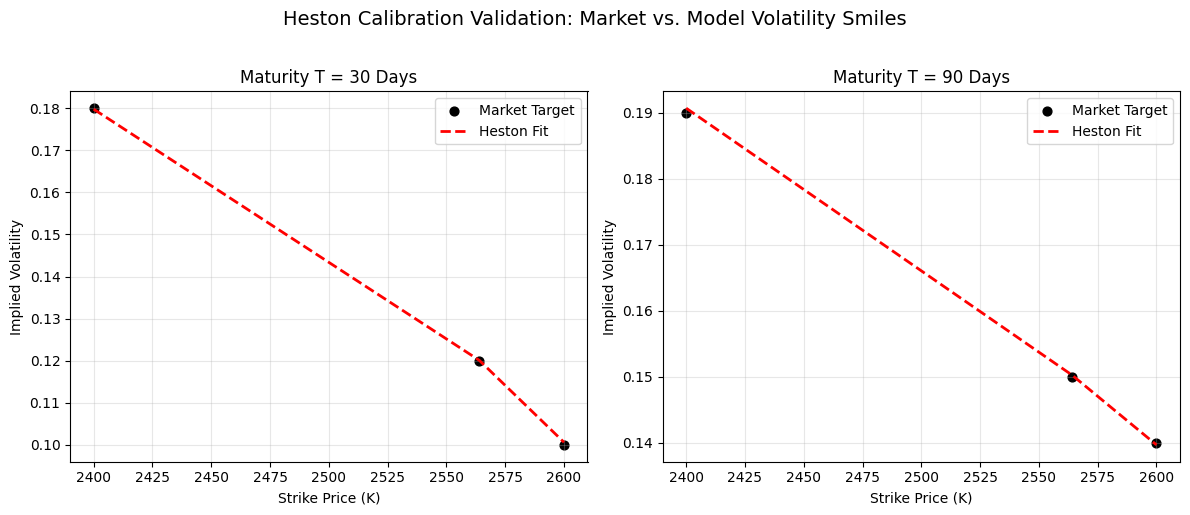

In [42]:
from calibration.fourier_ad import price_heston_lewis, implied_volatility

def plot_calibration_results(market_snapshot, calibrated_params):
    """
    Plots the Market IV vs. Calibrated Heston IV to visualize the quality of the fit.
    """
    df = market_snapshot['options']
    S = market_snapshot['spot']
    r = market_snapshot['r']
    q = market_snapshot.get('q', 0.0)
    
    # Extract calibrated model parameters
    kappa = calibrated_params['kappa']
    theta = calibrated_params['theta']
    sigma = calibrated_params['sigma']
    rho = calibrated_params['rho']
    v0 = calibrated_params['v0']
    
    # Generate model implied volatilities for every row in our dataset
    model_ivs = []
    for _, row in df.iterrows():
        K, T, market_iv = row['K'], row['T'], row['IV']
        
        # 1. Price using our GPU-native fixed grid Lewis pricer
        model_price = price_heston_lewis(S, K, T, r, q, kappa, theta, sigma, rho, v0)
        # 2. Invert back to IV using our Newton root-finder
        model_iv = implied_volatility(model_price, S, K, T, r, q)
        model_ivs.append(float(model_iv))
        
    df = df.copy()
    df['Model_IV'] = model_ivs
    
    # Group by unique maturities to plot separate smiles
    maturities = df['T'].unique()
    
    fig, axes = plt.subplots(1, len(maturities), figsize=(6 * len(maturities), 5), squeeze=False)
    
    for idx, T in enumerate(sorted(maturities)):
        ax = axes[0, idx]
        sub_df = df[df['T'] == T].sort_values(by='K')
        
        # Plot True Market Data
        ax.scatter(sub_df['K'], sub_df['IV'], color='black', marker='o', s=40, label='Market Target')
        # Plot Heston's Calibrated Fit
        ax.plot(sub_df['K'], sub_df['Model_IV'], color='red', lw=2, linestyle='--', label='Heston Fit')
        
        ax.set_title(f"Maturity T = {T*365:.0f} Days")
        ax.set_xlabel("Strike Price (K)")
        ax.set_ylabel("Implied Volatility")
        ax.grid(True, alpha=0.3)
        ax.legend()
        
    plt.suptitle("Heston Calibration Validation: Market vs. Model Volatility Smiles", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Run the function ---
# Pass your snapshot and the output dictionary from your calibration loop
plot_calibration_results(market_snapshot, calibrated_params)

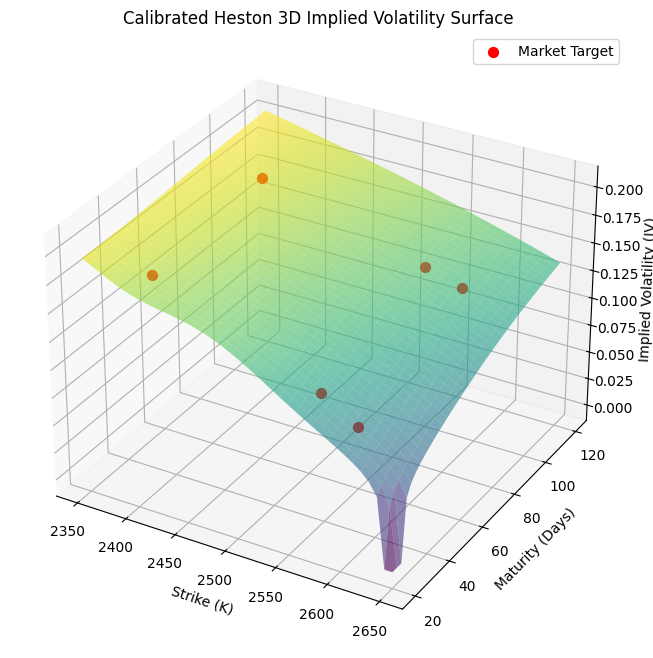

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from calibration.fourier_ad import price_heston_lewis, implied_volatility

def plot_3d_iv_surface(market_snapshot, calibrated_params):
    df = market_snapshot['options']
    S = market_snapshot['spot']
    r = market_snapshot['r']
    q = market_snapshot.get('q', 0.0)
    
    # 1. Create a dense grid for a smooth model surface plot
    # We span slightly beyond our raw data limits to see the surface stretch
    k_min, k_max = df['K'].min() - 50, df['K'].max() + 50
    t_min, t_max = df['T'].min() - 10/365, df['T'].max() + 30/365
    
    grid_K = np.linspace(k_min, k_max, 40)
    grid_T = np.linspace(max(1e-3, t_min), t_max, 40)
    mesh_K, mesh_T = np.meshgrid(grid_K, grid_T)
    
    # Pre-allocate surface array
    mesh_IV = np.zeros_like(mesh_K)
    
    # Extract calibrated model parameters
    kappa = calibrated_params['kappa']
    theta = calibrated_params['theta']
    sigma = calibrated_params['sigma']
    rho = calibrated_params['rho']
    v0 = calibrated_params['v0']
    
    # 2. Compute the theoretical Heston IV over the entire mesh grid
    for i in range(mesh_K.shape[0]):
        for j in range(mesh_K.shape[1]):
            K_val = float(mesh_K[i, j])
            T_val = float(mesh_T[i, j])
            
            # Price and invert to IV using our GPU-native fixed-grid functions
            price = price_heston_lewis(S, K_val, T_val, r, q, kappa, theta, sigma, rho, v0)
            iv = implied_volatility(price, S, K_val, T_val, r, q)
            mesh_IV[i, j] = float(iv)
            
    # 3. Plotting the 3D Graph
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the smooth, continuous calibrated Heston surface
    surf = ax.plot_surface(mesh_K, mesh_T * 365, mesh_IV, cmap='viridis', 
                           alpha=0.6, edgecolor='none', antialiased=True)
    
    # Scatter the actual, discrete market target data points on top
    ax.scatter(df['K'], df['T'] * 365, df['IV'], color='red', marker='o', s=50, depthshade=False, label='Market Target')
    
    ax.set_title("Calibrated Heston 3D Implied Volatility Surface")
    ax.set_xlabel("Strike (K)")
    ax.set_ylabel("Maturity (Days)")
    ax.set_zlabel("Implied Volatility (IV)")
    ax.legend()
    plt.show()

plot_3d_iv_surface(market_snapshot=market_snapshot, calibrated_params=calibrated_params)


In [44]:
# Calibrate Rough Bergomi (MC-AD)
# We pass calib_key to freeze the noise during the optimizer's gradient descent
bergomi_opt_params = calibrate_bergomi_mc_ad(
    market_snapshot, 
    static_key=calib_key, 
    model_type="rough", 
    steps=200, 
    lr=0.02
)
# Add required parameters for the simulator interface
bergomi_opt_params['S0'] = market_snapshot['spot']
bergomi_opt_params['r'] = market_snapshot['r']

print("\nCalibrated Rough Bergomi Parameters:", bergomi_opt_params)

# Setup parameters for simulation in next cell
N_PATHS = 2048
N_STEPS = 100
T_SIM = 1.0


Starting rough Bergomi MC-AD Calibration...
Step 0 | RMSE: 0.030383
Step 20 | RMSE: 0.022595
Step 40 | RMSE: 0.020543
Step 60 | RMSE: 0.019695
Step 80 | RMSE: 0.018917
Step 100 | RMSE: 0.018231
Step 120 | RMSE: 0.017758
Step 140 | RMSE: 0.017376
Step 160 | RMSE: 0.017044
Step 180 | RMSE: 0.016699

Calibrated Rough Bergomi Parameters: {'eta': 0.5805958617160787, 'rho': -0.8386354268504296, 'H': -0.03386884715319194, 'v0': 0.02362829977970716, 'S0': 2564.98, 'r': 0.0113}


In [45]:
# Generate shape (2048, 101, 2)
bergomi_paths = simulate_bergomi(
    params=bergomi_opt_params, 
    key=sim_key, 
    n_paths=N_PATHS, 
    n_steps=N_STEPS, 
    T=T_SIM, 
    model_type="rough"
)

print(f"Bergomi Tensor Shape: {bergomi_paths.shape}")

Bergomi Tensor Shape: (2048, 101, 2)


In [46]:
# Initialize the Signature Kernel from sigkerax
signature_kernel = SigKernel(refinement_factor=2, static_kernel_kind="linear")

print("Computing path-space Maximum Mean Discrepancy (MMD)...")
print("This compiles the Lead-Lag transformation and Cross-Kernel matrices via XLA.")

# Calculate the MMD^2 distance between the two calibrated models
# Note: We slice the simulated paths to 100 to prevent CPU memory/time explosion.
mmd_score = compute_sig_mmd(
    real_paths=heston_paths[:100],    # Treating Heston as the "baseline" target for this test
    sim_paths=bergomi_paths[:100],    # Treating Bergomi as the challenger
    static_kernel_fn=signature_kernel.kernel_matrix
)

print(f"Signature-MMD^2 (Heston vs. Rough Bergomi): {mmd_score:.6f}")


Computing path-space Maximum Mean Discrepancy (MMD)...
This compiles the Lead-Lag transformation and Cross-Kernel matrices via XLA.
Signature-MMD^2 (Heston vs. Rough Bergomi): 4.837957


<>:29: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:29: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/6g/xmgh_b_d4rz4b549wb6d2h0h0000gn/T/ipykernel_18318/1030022689.py:29: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax2.set_title("Rough Bergomi Normalized Log-Prices $\log(S_t/S_0)$")


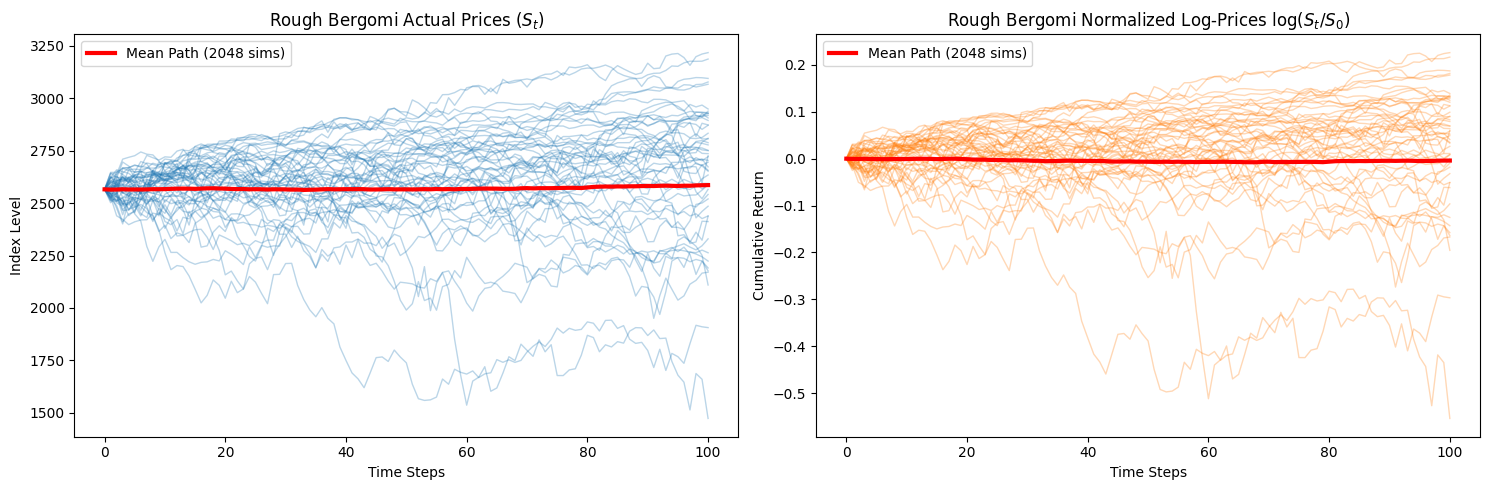

In [47]:
# Extract the log prices (feature 0) from the generated Bergomi tensor
# Shape is (2048, 101)
log_prices_rg = bergomi_paths[:, :, 0] 

# --- 1. Math for Actual Prices ---
actual_prices_rg = jnp.exp(log_prices_rg)
average_actual_price_rg = jnp.mean(actual_prices_rg, axis=0)

# --- 2. Math for Normalized Log-Prices ---
normalized_log_prices_rg = log_prices_rg - log_prices_rg[:, 0:1]
average_norm_log_rg = jnp.mean(normalized_log_prices_rg, axis=0)

# --- 3. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i in range(50): 
    ax1.plot(actual_prices_rg[i, :], lw=1, alpha=0.3, color='tab:blue') 

ax1.plot(average_actual_price_rg, lw=3, color='red', label='Mean Path (2048 sims)')
ax1.set_title("Rough Bergomi Actual Prices ($S_t$)")
ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Index Level")
ax1.legend()

for i in range(50):
    ax2.plot(normalized_log_prices_rg[i, :], lw=1, alpha=0.3, color='tab:orange')

ax2.plot(average_norm_log_rg, lw=3, color='red', label='Mean Path (2048 sims)')
ax2.set_title("Rough Bergomi Normalized Log-Prices $\log(S_t/S_0)$")
ax2.set_xlabel("Time Steps")
ax2.set_ylabel("Cumulative Return")
ax2.legend()

plt.tight_layout()


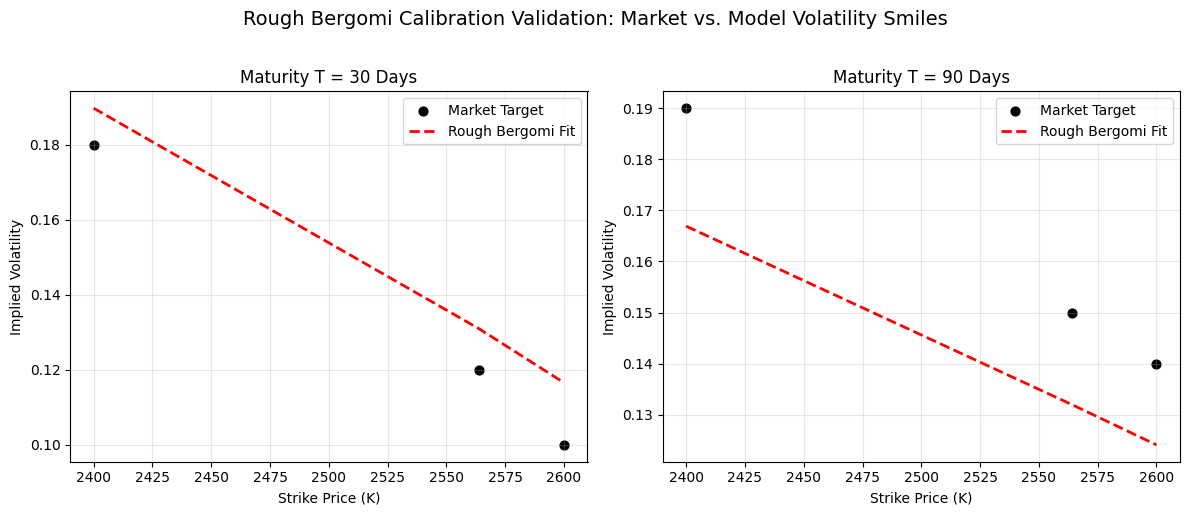

In [51]:
from calibration.bergomi_mc_ad import bergomi_mc_pricer
from calibration.fourier_ad import implied_volatility

def plot_bergomi_calibration_results(market_snapshot, calibrated_params, static_key, model_type="rough"):
    df = market_snapshot['options']
    S = market_snapshot['spot']
    r = market_snapshot['r']
    q = market_snapshot.get('q', 0.0)
    
    model_ivs = []
    for _, row in df.iterrows():
        K, T, market_iv = row['K'], row['T'], row['IV']
        price = bergomi_mc_pricer(calibrated_params, static_key, S, K, T, r, q, model_type)
        model_iv = implied_volatility(price, S, K, T, r, q)
        model_ivs.append(float(model_iv))
        
    df = df.copy()
    df['Model_IV'] = model_ivs
    
    maturities = df['T'].unique()
    fig, axes = plt.subplots(1, len(maturities), figsize=(6 * len(maturities), 5), squeeze=False)
    
    for idx, T in enumerate(sorted(maturities)):
        ax = axes[0, idx]
        sub_df = df[df['T'] == T].sort_values(by='K')
        
        ax.scatter(sub_df['K'], sub_df['IV'], color='black', marker='o', s=40, label='Market Target')
        ax.plot(sub_df['K'], sub_df['Model_IV'], color='red', lw=2, linestyle='--', label=f'{model_type.capitalize()} Bergomi Fit')
        
        ax.set_title(f"Maturity T = {T*365:.0f} Days")
        ax.set_xlabel("Strike Price (K)")
        ax.set_ylabel("Implied Volatility")
        ax.grid(True, alpha=0.3)
        ax.legend()
        
    epsilon_str = f" (eps={calibrated_params.get('epsilon')})" if model_type == 'path_dependent' else ""
    plt.suptitle(f"{model_type.capitalize()} Bergomi Calibration Validation{epsilon_str}: Market vs. Model Volatility Smiles", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_bergomi_calibration_results(market_snapshot, calibrated_params=bergomi_opt_params, static_key=key)

Computing rough 3D IV Surface...


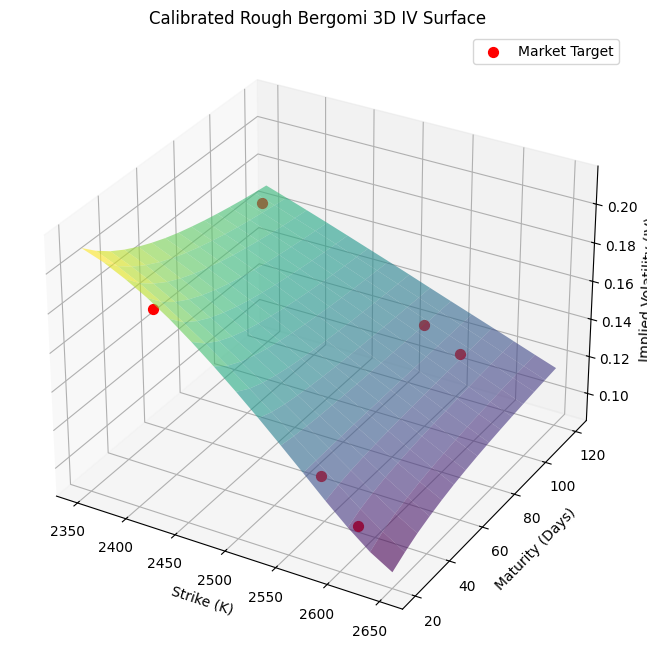

In [52]:
def plot_bergomi_3d_iv_surface(market_snapshot, calibrated_params, static_key, model_type="rough", grid_size=15):
    df = market_snapshot['options']
    S = market_snapshot['spot']
    r = market_snapshot['r']
    q = market_snapshot.get('q', 0.0)
    
    # Use a smaller grid for MC pricing to save time
    k_min, k_max = df['K'].min() - 50, df['K'].max() + 50
    t_min, t_max = df['T'].min() - 10/365, df['T'].max() + 30/365
    
    grid_K = np.linspace(k_min, k_max, grid_size)
    grid_T = np.linspace(max(1e-3, t_min), t_max, grid_size)
    mesh_K, mesh_T = np.meshgrid(grid_K, grid_T)
    mesh_IV = np.zeros_like(mesh_K)
    
    # We can batch the inner loop using vmap for speed
    from functools import partial
    
    @partial(jax.jit, static_argnums=(7,))
    def get_ivs_for_row(K_row, T_val, params, key, S, r, q, model_type):
        def single_iv(K):
            price = bergomi_mc_pricer(params, key, S, K, T_val, r, q, model_type)
            return implied_volatility(price, S, K, T_val, r, q)
        return jax.vmap(single_iv)(K_row)

    print(f"Computing {model_type} 3D IV Surface...")
    for i in range(mesh_K.shape[0]):
        T_val = float(mesh_T[i, 0])
        K_row = jnp.array(mesh_K[i, :])
        iv_row = get_ivs_for_row(K_row, T_val, calibrated_params, static_key, S, r, q, model_type)
        mesh_IV[i, :] = np.array(iv_row)
            
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(mesh_K, mesh_T * 365, mesh_IV, cmap='viridis', 
                           alpha=0.6, edgecolor='none', antialiased=True)
    
    ax.scatter(df['K'], df['T'] * 365, df['IV'], color='red', marker='o', s=50, depthshade=False, label='Market Target')
    
    epsilon_str = f" (eps={calibrated_params.get('epsilon')})" if model_type == 'path_dependent' else ""
    ax.set_title(f"Calibrated {model_type.capitalize()} Bergomi 3D IV Surface{epsilon_str}")
    ax.set_xlabel("Strike (K)")
    ax.set_ylabel("Maturity (Days)")
    ax.set_zlabel("Implied Volatility (IV)")
    ax.legend()
    plt.show()

plot_bergomi_3d_iv_surface(market_snapshot, calibrated_params=bergomi_opt_params, static_key=key, model_type="rough")


<>:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/6g/xmgh_b_d4rz4b549wb6d2h0h0000gn/T/ipykernel_18318/2063486474.py:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax2.set_title(f"PD-Bergomi Normalized Log-Prices $\log(S_t/S_0)$ (eps={eps:.4f})")



--- Approximated Bergomi (PD-Bergomi) with epsilon = 0.0192 ---


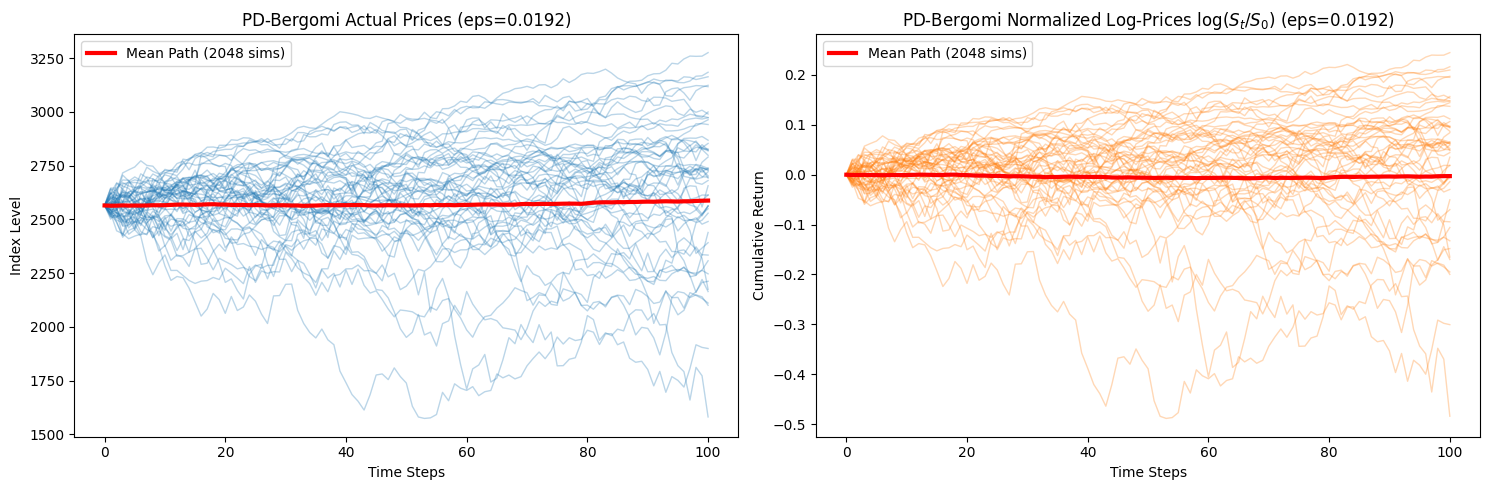

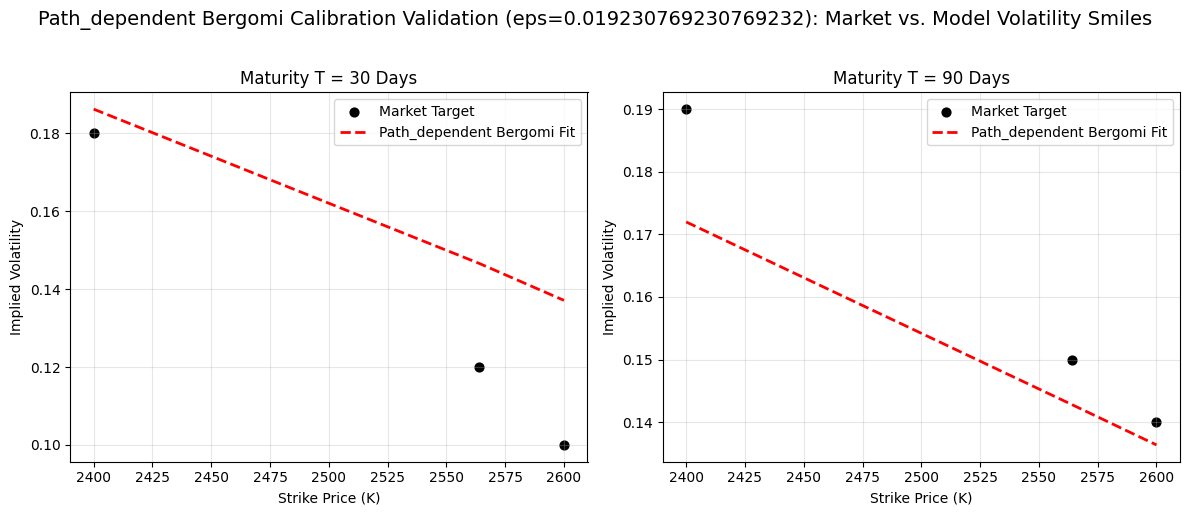


--- Approximated Bergomi (PD-Bergomi) with epsilon = 0.0833 ---


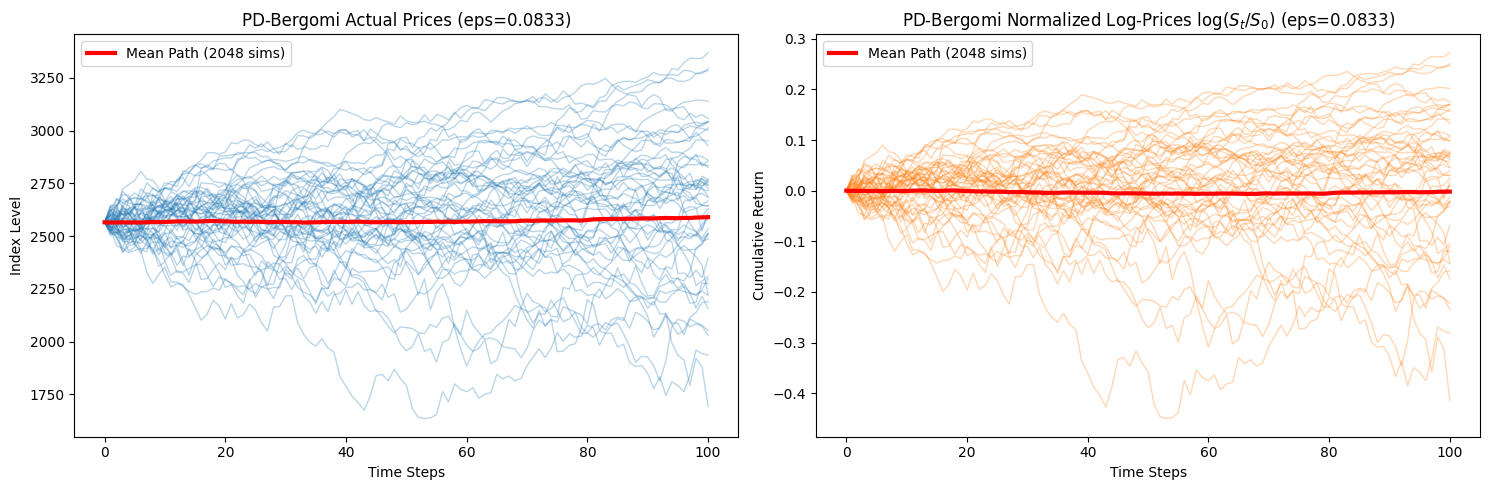

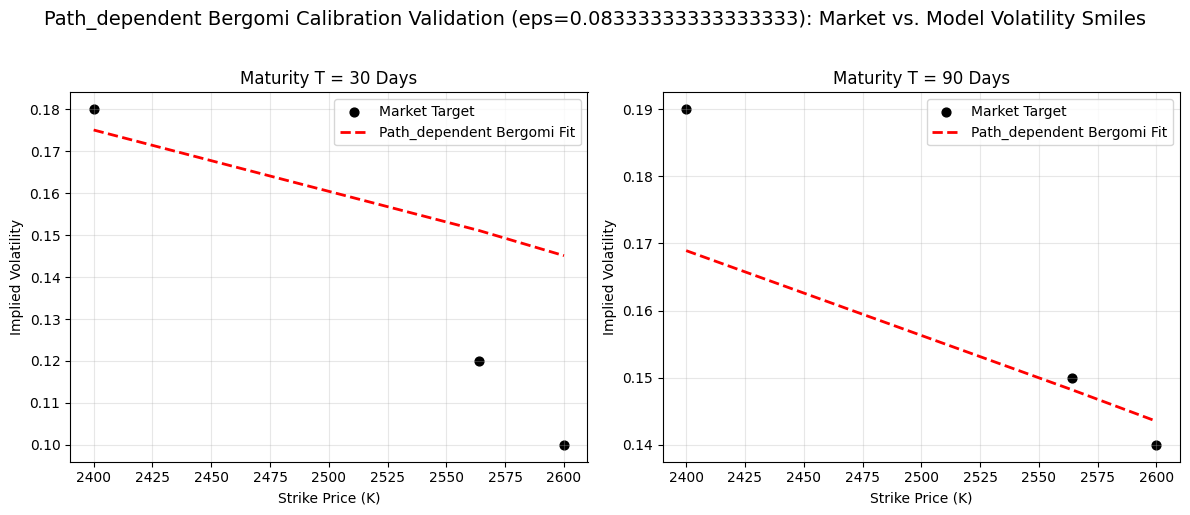


--- Approximated Bergomi (PD-Bergomi) with epsilon = 0.2500 ---


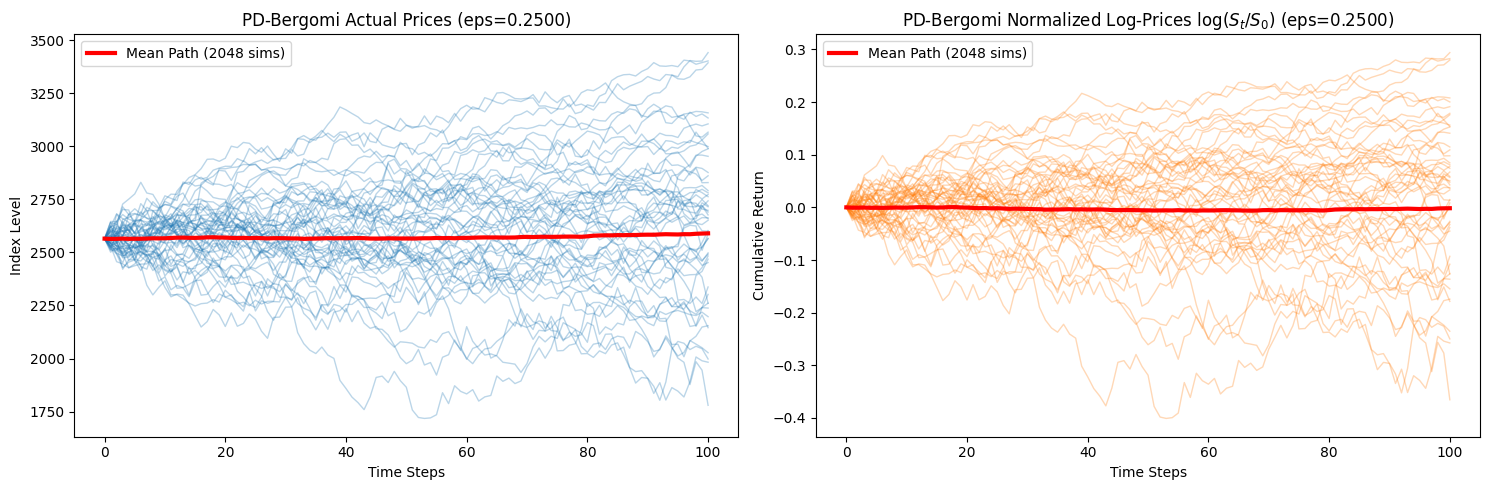

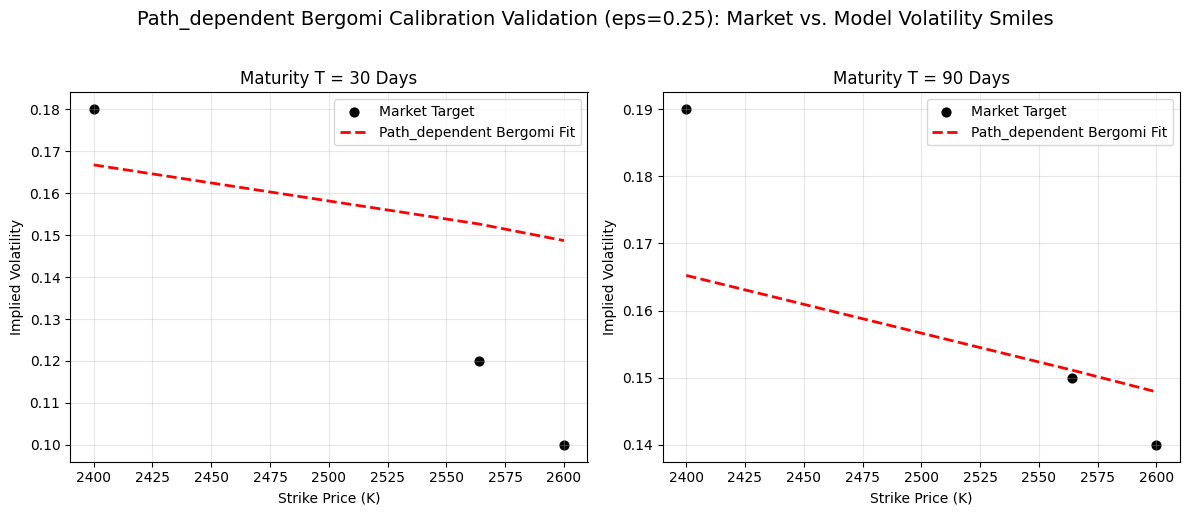

In [53]:
epsilons = [1/52, 1/12, 1/4] # e.g. 1 week, 1 month, 3 months

for eps in epsilons:
    print(f"\n--- Approximated Bergomi (PD-Bergomi) with epsilon = {eps:.4f} ---")
    
    pd_params = bergomi_opt_params.copy()
    pd_params['epsilon'] = eps
    
    # Simulate
    pd_paths = simulate_bergomi(
        params=pd_params, 
        key=sim_key, 
        n_paths=N_PATHS, 
        n_steps=N_STEPS, 
        T=T_SIM, 
        model_type="path_dependent"
    )
    
    # Plot Paths
    log_prices_pd = pd_paths[:, :, 0] 
    actual_prices_pd = jnp.exp(log_prices_pd)
    average_actual_price_pd = jnp.mean(actual_prices_pd, axis=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for i in range(50): 
        ax1.plot(actual_prices_pd[i, :], lw=1, alpha=0.3, color='tab:blue') 
    ax1.plot(average_actual_price_pd, lw=3, color='red', label='Mean Path (2048 sims)')
    ax1.set_title(f"PD-Bergomi Actual Prices (eps={eps:.4f})")
    ax1.set_xlabel("Time Steps")
    ax1.set_ylabel("Index Level")
    ax1.legend()

    normalized_log_prices_pd = log_prices_pd - log_prices_pd[:, 0:1]
    average_norm_log_pd = jnp.mean(normalized_log_prices_pd, axis=0)

    for i in range(50):
        ax2.plot(normalized_log_prices_pd[i, :], lw=1, alpha=0.3, color='tab:orange')
    ax2.plot(average_norm_log_pd, lw=3, color='red', label='Mean Path (2048 sims)')
    ax2.set_title(f"PD-Bergomi Normalized Log-Prices $\log(S_t/S_0)$ (eps={eps:.4f})")
    ax2.set_xlabel("Time Steps")
    ax2.set_ylabel("Cumulative Return")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Plot IV Slice
    plot_bergomi_calibration_results(market_snapshot, pd_params, calib_key, model_type="path_dependent")
    
    # Plot 3D IV Surface
